# Seeded Subvolume Comparison (Baseline-Matched)

This notebook isolates the seeded runs and compares them against the original baseline workflow using the same convergence metric:

- metric: mean of $r^2\xi(r)$ over $3 \le r \le 20$ Mpc/h
- normalization: metric divided by the largest available $n_{\mathrm{subvol}}$ reference

The sections below load baseline and seeded outputs, generate seeded series with explicit seed control, overlay comparisons, compute pointwise residuals, and run a reproducibility check.

## 1) Import Libraries and Configure Plot Style

Imports and plotting defaults are aligned with the prior comparison notebook so visual interpretation remains consistent.

In [43]:
import re
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    fallback = Path("/cosma/home/durham/dc-hick2/galform_analysis")
    return fallback if fallback.exists() else start


project_root = find_repo_root(Path.cwd().resolve())
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from galform_analysis.utils.matplotlib_config import setconfig


setconfig()
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

RMIN, RMAX = 3.0, 20.0
MODE_MAP = {
    "standard": "normal",
    "normal": "normal",
    "halo": "weighted",
    "weighted": "weighted",
}
MODEL_NAMES = {"gp14", "lc16"}


REPO_ROOT = project_root
DATA_ROOT = REPO_ROOT / "data"
BASELINE_ROOT = DATA_ROOT / "halo_sampling_4_subvol_weighted_random"
SEEDED_ROOT = DATA_ROOT / "halo_sampling_4_subvol_weighted_random_seeded"

print(f"Repo root: {REPO_ROOT}")
print(f"Baseline root exists: {BASELINE_ROOT.exists()}")
print(f"Seeded root exists: {SEEDED_ROOT.exists()}")

Repo root: /cosma/home/durham/dc-hick2/galform_analysis
Baseline root exists: True
Seeded root exists: True


## 2) Load or Recreate Baseline Data for Previous Comparison

This cell rebuilds the same scalar convergence metric used earlier and computes metric/ref curves for both baseline and seeded outputs.

In [44]:
def infer_model_from_path(path: Path) -> str:
    lowered_parts = [p.lower() for p in path.parts]
    for model in MODEL_NAMES:
        if model in lowered_parts:
            return model
    return "legacy"


def extract_tag(parts, prefix, cast=str, default=np.nan):
    for part in parts:
        if part.startswith(prefix):
            value = part.split("_", 1)[1]
            try:
                return cast(value)
            except Exception:
                return default
    return default


def load_random_outputs(root: Path, source_label: str) -> pd.DataFrame:
    pattern = re.compile(r"halo_sampling_convergence_(standard|weighted|normal|halo)_(.+)_iz(\d+)\.csv$")
    frames = []

    if not root.exists():
        return pd.DataFrame()

    for csv_path in root.rglob("halo_sampling_convergence_*_iz*.csv"):
        match = pattern.match(csv_path.name)
        if not match:
            continue

        mode_raw, sim, iz = match.groups()

        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:
            print(f"Failed reading {csv_path}: {exc}")
            continue

        if df.empty:
            continue

        parts = csv_path.parts
        out = df.copy()
        out["source_label"] = source_label
        out["source_file"] = str(csv_path)
        out["model"] = infer_model_from_path(csv_path)
        out["mode_raw"] = mode_raw
        out["mode_norm"] = MODE_MAP.get(mode_raw, mode_raw)
        out["sim"] = sim
        out["iz"] = int(iz)

        out["mhalo_tag"] = extract_tag(parts, "mhalo_", cast=str, default="unknown")
        out["centrals_only"] = extract_tag(parts, "centrals_", cast=int, default=np.nan)
        n_subvol_from_path = extract_tag(parts, "nsubvol_", cast=int, default=np.nan)
        seed_from_path = extract_tag(parts, "seed_", cast=int, default=np.nan)

        if "n_subvol" not in out.columns:
            out["n_subvol"] = n_subvol_from_path
        if "selection_seed" not in out.columns:
            out["selection_seed"] = seed_from_path

        frames.append(out)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    out["r"] = pd.to_numeric(out.get("r", np.nan), errors="coerce")
    out["xi"] = pd.to_numeric(out.get("xi", np.nan), errors="coerce")
    out["n_subvol"] = pd.to_numeric(out.get("n_subvol", np.nan), errors="coerce").astype("Int64")
    out["selection_seed"] = pd.to_numeric(out.get("selection_seed", np.nan), errors="coerce").astype("Int64")
    out["centrals_only"] = pd.to_numeric(out.get("centrals_only", np.nan), errors="coerce").astype("Int64")
    out["iz"] = pd.to_numeric(out.get("iz", np.nan), errors="coerce").astype("Int64")
    return out


def infer_xi_shift(
    baseline_df: pd.DataFrame,
    seeded_df: pd.DataFrame,
    convention: str = "auto",
    large_scale_rmin: float = 8.0,
) -> tuple[float, str, float, float]:
    def tail_median(df: pd.DataFrame) -> float:
        if df.empty or "r" not in df.columns or "xi" not in df.columns:
            return np.nan
        r = pd.to_numeric(df["r"], errors="coerce")
        xi = pd.to_numeric(df["xi"], errors="coerce")
        tail = xi[r >= large_scale_rmin].dropna()
        return float(tail.median()) if not tail.empty else np.nan

    base_tail_med = tail_median(baseline_df)
    seed_tail_med = tail_median(seeded_df)

    mode = str(convention).strip().lower()
    if mode == "1+xi":
        shift = 1.0
    elif mode == "xi":
        shift = 0.0
    else:
        near_one_base = np.isfinite(base_tail_med) and (0.7 <= base_tail_med <= 1.3)
        near_one_seed = np.isfinite(seed_tail_med) and (0.7 <= seed_tail_med <= 1.3)
        shift = 1.0 if (near_one_base and near_one_seed) else 0.0

    label = "xi=(1+xi)-1" if shift == 1.0 else "xi"
    return shift, label, base_tail_med, seed_tail_med


def build_metric(df: pd.DataFrame, include_seed: bool, xi_shift: float = 0.0) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    usable = df.dropna(subset=["r", "xi", "n_subvol"]).copy()
    usable = usable[(usable["r"] >= RMIN) & (usable["r"] <= RMAX)]
    if usable.empty:
        return pd.DataFrame()

    usable["xi_metric"] = usable["xi"] - xi_shift
    usable["metric"] = (usable["r"] ** 2) * usable["xi_metric"]
    group_cols = ["model", "sim", "iz", "mode_norm", "mhalo_tag", "centrals_only", "n_subvol"]
    if include_seed:
        usable["selection_seed"] = usable["selection_seed"].fillna(-1).astype(int)
        group_cols = group_cols[:-1] + ["selection_seed", "n_subvol"]

    metric = (
        usable.groupby(group_cols, as_index=False)
        .agg(metric=("metric", "mean"), n_points=("metric", "size"))
        .sort_values(group_cols)
    )
    return metric


def add_frac_to_ref(metric_df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if metric_df.empty:
        return metric_df

    ref = (
        metric_df.sort_values("n_subvol")
        .groupby(group_cols, as_index=False)
        .tail(1)
        .rename(columns={"n_subvol": "n_subvol_ref", "metric": "metric_ref"})
    )
    out = metric_df.merge(ref[group_cols + ["n_subvol_ref", "metric_ref"]], on=group_cols, how="left")
    out["frac_to_ref"] = out["metric"] / out["metric_ref"]
    out["abs_frac_error"] = (out["frac_to_ref"] - 1.0).abs()
    return out


baseline_raw = load_random_outputs(BASELINE_ROOT, source_label="baseline")
seeded_raw = load_random_outputs(SEEDED_ROOT, source_label="seeded")

XI_METRIC_INPUT_CONVENTION = "auto"  # "auto", "xi", or "1+xi"
XI_METRIC_LARGE_SCALE_RMIN = 8.0

xi_shift_metric, metric_convention_label, base_tail_med_metric, seed_tail_med_metric = infer_xi_shift(
    baseline_raw,
    seeded_raw,
    convention=XI_METRIC_INPUT_CONVENTION,
    large_scale_rmin=XI_METRIC_LARGE_SCALE_RMIN,
)

BASELINE_METRIC = build_metric(baseline_raw, include_seed=False, xi_shift=xi_shift_metric)
SEEDED_METRIC = build_metric(seeded_raw, include_seed=True, xi_shift=xi_shift_metric)

combo_cols = ["model", "sim", "iz", "mode_norm", "mhalo_tag", "centrals_only"]
BASELINE_CURVE = add_frac_to_ref(BASELINE_METRIC, group_cols=combo_cols)
SEEDED_CURVE_ALL = add_frac_to_ref(SEEDED_METRIC, group_cols=combo_cols + ["selection_seed"])

print(
    f"Metric xi convention (r>={XI_METRIC_LARGE_SCALE_RMIN}): "
    f"baseline median={base_tail_med_metric:.4g}, seeded median={seed_tail_med_metric:.4g}; "
    f"applying shift={xi_shift_metric:.1f} ({metric_convention_label})."
)
print(f"Baseline rows: {len(baseline_raw)} | metric rows: {len(BASELINE_CURVE)}")
print(f"Seeded rows: {len(seeded_raw)} | metric rows: {len(SEEDED_CURVE_ALL)}")

if not BASELINE_CURVE.empty:
    print("Baseline combo count:", BASELINE_CURVE[combo_cols].drop_duplicates().shape[0])
if not SEEDED_CURVE_ALL.empty:
    print("Seeded combo count:", SEEDED_CURVE_ALL[combo_cols].drop_duplicates().shape[0])

if not SEEDED_CURVE_ALL.empty:
    display(
        SEEDED_CURVE_ALL[
            combo_cols + ["selection_seed", "n_subvol", "frac_to_ref", "abs_frac_error"]
        ]
        .sort_values(combo_cols + ["selection_seed", "n_subvol"])
        .head(20)
    )

Metric xi convention (r>=8.0): baseline median=1.115, seeded median=1.107; applying shift=1.0 (xi=(1+xi)-1).
Baseline rows: 5660 | metric rows: 261
Seeded rows: 5680 | metric rows: 264
Baseline combo count: 18
Seeded combo count: 18


,model,sim,iz,mode_norm,mhalo_tag,centrals_only,selection_seed,n_subvol,frac_to_ref,abs_frac_error
0,lc16,L800,155,weighted,1e11,0,271828,2,0.910577,0.089423
1,lc16,L800,155,weighted,1e11,0,271828,4,-0.076322,1.076322
2,lc16,L800,155,weighted,1e11,0,271828,8,0.312409,0.687591
3,lc16,L800,155,weighted,1e11,0,271828,10,0.553609,0.446391
4,lc16,L800,155,weighted,1e11,0,271828,15,0.419029,0.580971
5,lc16,L800,155,weighted,1e11,0,271828,20,0.649820,0.350180
6,lc16,L800,155,weighted,1e11,0,271828,25,0.802731,0.197269
7,lc16,L800,155,weighted,1e11,0,271828,30,0.835429,0.164571
8,lc16,L800,155,weighted,1e11,0,271828,50,0.890955,0.109045
9,lc16,L800,155,weighted,1e11,0,271828,100,0.941380,0.058620


## 3) Set Random Seed and Generate Seeded Series

We keep the same metric construction and only control the explicit seed subset for seeded-series inspection.

In [45]:
ANALYSIS_RANDOM_SEED = 20260313
MAX_PANELS = 12

available_seeds = []
if not SEEDED_CURVE_ALL.empty:
    available_seeds = sorted(SEEDED_CURVE_ALL["selection_seed"].dropna().astype(int).unique().tolist())

# Explicit fixed seeds for repeatable comparisons.
FIXED_SEEDS = available_seeds[:8]

if not FIXED_SEEDS:
    SEEDED_CURVE = SEEDED_CURVE_ALL.copy()
    print("No explicit seeds discovered in seeded outputs; using all rows as-is.")
else:
    SEEDED_CURVE = SEEDED_CURVE_ALL[SEEDED_CURVE_ALL["selection_seed"].isin(FIXED_SEEDS)].copy()

print("Analysis random seed:", ANALYSIS_RANDOM_SEED)
print("Seeds used in plots:", FIXED_SEEDS if FIXED_SEEDS else "all available")
print("Seeded curve rows used:", len(SEEDED_CURVE))

combo_cols = ["model", "sim", "iz", "mode_norm", "mhalo_tag", "centrals_only"]
available_combos = (
    SEEDED_CURVE[combo_cols].drop_duplicates().sort_values(combo_cols).reset_index(drop=True)
    if not SEEDED_CURVE.empty
    else pd.DataFrame(columns=combo_cols)
)

if len(available_combos) > MAX_PANELS:
    rng = np.random.default_rng(ANALYSIS_RANDOM_SEED)
    keep_idx = np.sort(rng.choice(len(available_combos), size=MAX_PANELS, replace=False))
    PANEL_COMBOS = available_combos.iloc[keep_idx].reset_index(drop=True)
else:
    PANEL_COMBOS = available_combos.copy()

print(f"Panel combos selected: {len(PANEL_COMBOS)}")
if not PANEL_COMBOS.empty:
    display(PANEL_COMBOS.head(12))

Analysis random seed: 20260313
Seeds used in plots: [271828]
Seeded curve rows used: 264
Panel combos selected: 12


,model,sim,iz,mode_norm,mhalo_tag,centrals_only
0,lc16,L800,155,weighted,1e11,0
1,lc16,L800,155,weighted,1e11,1
2,lc16,L800,155,weighted,1e13,0
3,lc16,L800,155,weighted,1e9,0
4,lc16,L800,155,weighted,1e9,1
5,lc16,L800,207,weighted,1e11,1
6,lc16,L800,207,weighted,1e13,0
7,lc16,L800,207,weighted,1e13,1
8,lc16,L800,271,weighted,1e11,1
9,lc16,L800,271,weighted,1e13,0


## 4) Plot Seeded Results Against Baseline

Each panel overlays baseline and seeded metric/ref curves with the same normalization and axis conventions as before.

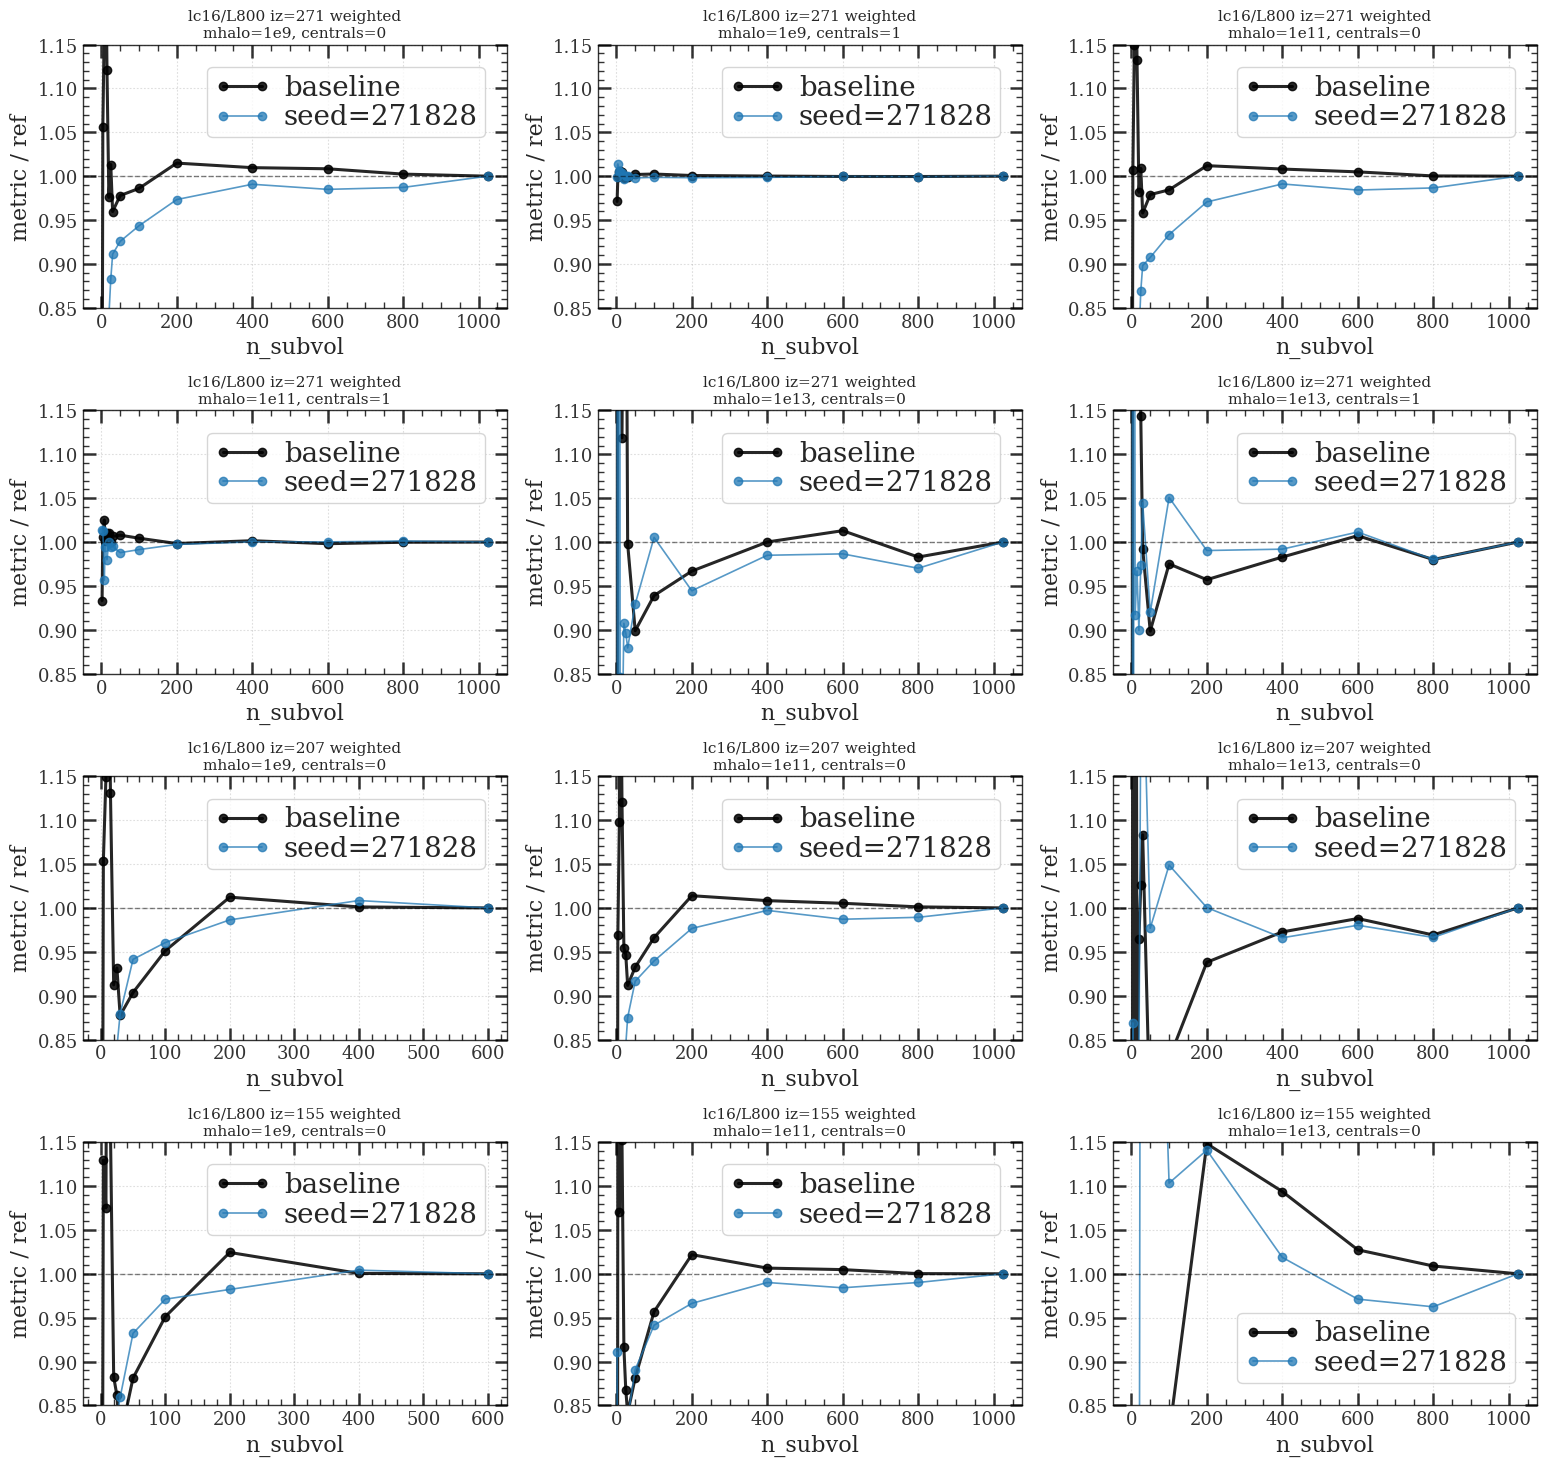

In [58]:
preferred_focus = [
    ("lc16", "L800", 271, "weighted", "1e9", 0),
    ("lc16", "L800", 271, "weighted", "1e9", 1),
    ("lc16", "L800", 271, "weighted", "1e11", 0),
    ("lc16", "L800", 271, "weighted", "1e11", 1),
    ("lc16", "L800", 271, "weighted", "1e13", 0),
    ("lc16", "L800", 271, "weighted", "1e13", 1),
    ("lc16", "L800", 207, "weighted", "1e9", 0),
    ("lc16", "L800", 207, "weighted", "1e11", 0),
    ("lc16", "L800", 207, "weighted", "1e13", 0),
    ("lc16", "L800", 155, "weighted", "1e9", 0),
    ("lc16", "L800", 155, "weighted", "1e11", 0),
    ("lc16", "L800", 155, "weighted", "1e13", 0),
]

if SEEDED_CURVE.empty:
    print("No seeded metric/ref rows available for plotting.")
else:
    available_keys = set(
        SEEDED_CURVE[combo_cols].drop_duplicates().itertuples(index=False, name=None)
    )
    panels = [key for key in preferred_focus if key in available_keys]

    if not panels and not PANEL_COMBOS.empty:
        panels = [tuple(row) for row in PANEL_COMBOS.itertuples(index=False, name=None)]

    if not panels:
        print("No overlapping seeded combos available yet.")
    else:
        ncols = 3
        nrows = int(np.ceil(len(panels) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.7 * nrows), squeeze=False)
        axes = axes.ravel()

        for i, key in enumerate(panels):
            ax = axes[i]
            model, sim, iz, mode_norm, mhalo_tag, centrals_only = key

            base = BASELINE_CURVE[
                (BASELINE_CURVE["model"] == model)
                & (BASELINE_CURVE["sim"] == sim)
                & (BASELINE_CURVE["iz"] == iz)
                & (BASELINE_CURVE["mode_norm"] == mode_norm)
                & (BASELINE_CURVE["mhalo_tag"] == mhalo_tag)
                & (BASELINE_CURVE["centrals_only"] == centrals_only)
            ].sort_values("n_subvol")

            seed = SEEDED_CURVE[
                (SEEDED_CURVE["model"] == model)
                & (SEEDED_CURVE["sim"] == sim)
                & (SEEDED_CURVE["iz"] == iz)
                & (SEEDED_CURVE["mode_norm"] == mode_norm)
                & (SEEDED_CURVE["mhalo_tag"] == mhalo_tag)
                & (SEEDED_CURVE["centrals_only"] == centrals_only)
            ].sort_values(["selection_seed", "n_subvol"])

            if not base.empty:
                ax.plot(
                    base["n_subvol"],
                    base["frac_to_ref"],
                    marker="o",
                    lw=2.2,
                    color="black",
                    alpha=0.85,
                    label="baseline",
                )

            for seed_id, sdf in seed.groupby("selection_seed"):
                label = f"seed={seed_id}" if seed_id >= 0 else "seed=unknown"
                ax.plot(sdf["n_subvol"], sdf["frac_to_ref"], marker="o", lw=1.2, alpha=0.75, label=label)

            ax.axhline(1.0, ls="--", lw=1.0, color="k", alpha=0.5)
            ax.set_ylim(0.85, 1.15)
            ax.grid(alpha=0.25)
            ax.set_title(
                f"{model}/{sim} iz={int(iz)} {mode_norm}\nmhalo={mhalo_tag}, centrals={int(centrals_only)}"
            )
            ax.set_xlabel("n_subvol")
            ax.set_ylabel("metric / ref")

            handles, labels = ax.get_legend_handles_labels()
            if len(handles) <= 6:
                ax.legend(loc="best", frameon=True)

        for j in range(len(panels), len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

## 4b) Plot Actual 2PCF Curves $\xi(r)$

This section plots the direct correlation functions for baseline and seeded outputs, using a matched $n_{\mathrm{subvol}}$ per combo (default is the largest common value).

It also supports conventions where files store either $\xi$ or $(1+\xi)$; with `XI_INPUT_CONVENTION = "auto"`, the cell checks large-scale values and subtracts 1 when the asymptote is near 1.

Large-scale median (r>=8.0): baseline=1.115, seeded=1.107; applying shift=1.0 (xi=(1+xi)-1).


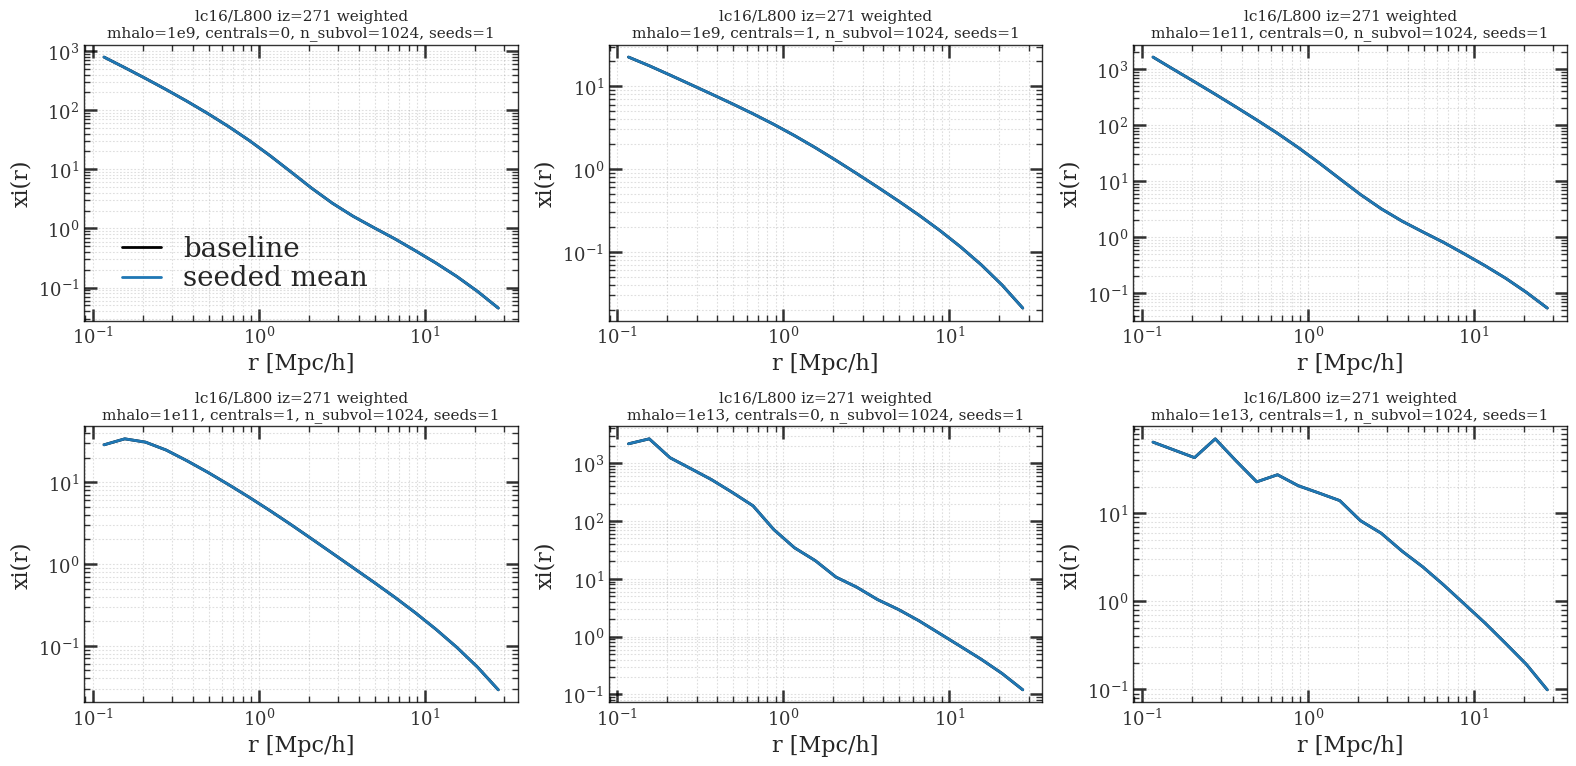

In [59]:
PLOT_2PCF_MAX_PANELS = 6
PLOT_2PCF_ALL_SEEDS = False  # keep plots readable: show baseline + seeded mean (+/-1 sigma) only
N_SUBVOL_2PCF = "max"  # "max" or integer target
XI_INPUT_CONVENTION = "auto"  # "auto", "xi", or "1+xi"
LARGE_SCALE_RMIN = 8.0

if baseline_raw.empty or seeded_raw.empty:
    print("Need both baseline and seeded raw data to plot direct 2PCF curves.")
else:
    raw_base = baseline_raw.copy()
    raw_seed = seeded_raw.copy()

    for df in (raw_base, raw_seed):
        df["r"] = pd.to_numeric(df.get("r", np.nan), errors="coerce")
        df["xi"] = pd.to_numeric(df.get("xi", np.nan), errors="coerce")
        df["n_subvol"] = pd.to_numeric(df.get("n_subvol", np.nan), errors="coerce").astype("Int64")
        if "mode_norm" not in df.columns:
            df["mode_norm"] = df["mode"].map(MODE_MAP).fillna(df["mode"])

    if "selection_seed" not in raw_seed.columns:
        raw_seed["selection_seed"] = -1
    raw_seed["selection_seed"] = pd.to_numeric(raw_seed["selection_seed"], errors="coerce").fillna(-1).astype(int)

    raw_base = raw_base.dropna(subset=["r", "xi", "n_subvol"]).copy()
    raw_seed = raw_seed.dropna(subset=["r", "xi", "n_subvol"]).copy()

    base_tail = raw_base.loc[raw_base["r"] >= LARGE_SCALE_RMIN, "xi"].dropna()
    seed_tail = raw_seed.loc[raw_seed["r"] >= LARGE_SCALE_RMIN, "xi"].dropna()
    base_tail_med = float(base_tail.median()) if not base_tail.empty else np.nan
    seed_tail_med = float(seed_tail.median()) if not seed_tail.empty else np.nan

    if XI_INPUT_CONVENTION == "1+xi":
        xi_shift = 1.0
    elif XI_INPUT_CONVENTION == "xi":
        xi_shift = 0.0
    else:
        near_one_base = np.isfinite(base_tail_med) and (0.7 <= base_tail_med <= 1.3)
        near_one_seed = np.isfinite(seed_tail_med) and (0.7 <= seed_tail_med <= 1.3)
        xi_shift = 1.0 if (near_one_base and near_one_seed) else 0.0

    convention_label = "xi=(1+xi)-1" if xi_shift == 1.0 else "xi"
    print(
        f"Large-scale median (r>={LARGE_SCALE_RMIN}): baseline={base_tail_med:.4g}, "
        f"seeded={seed_tail_med:.4g}; applying shift={xi_shift:.1f} ({convention_label})."
    )

    combo_cols_2pcf = ["model", "sim", "iz", "mode_norm", "mhalo_tag", "centrals_only"]
    base_keys = set(raw_base[combo_cols_2pcf].drop_duplicates().itertuples(index=False, name=None))
    seed_keys = set(raw_seed[combo_cols_2pcf].drop_duplicates().itertuples(index=False, name=None))
    common_keys = base_keys.intersection(seed_keys)

    focus_keys = preferred_focus if "preferred_focus" in globals() else []
    panels = [k for k in focus_keys if k in common_keys]
    if not panels:
        panels = sorted(common_keys)
    panels = panels[:PLOT_2PCF_MAX_PANELS]

    if not panels:
        print("No baseline-seeded combo overlap found for direct 2PCF plotting.")
    else:
        ncols = 3
        nrows = int(np.ceil(len(panels) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 3.9 * nrows), squeeze=False)
        axes = axes.ravel()

        for i, key in enumerate(panels):
            ax = axes[i]
            model, sim, iz, mode_norm, mhalo_tag, centrals_only = key

            base_combo = raw_base[
                (raw_base["model"] == model)
                & (raw_base["sim"] == sim)
                & (raw_base["iz"] == iz)
                & (raw_base["mode_norm"] == mode_norm)
                & (raw_base["mhalo_tag"] == mhalo_tag)
                & (raw_base["centrals_only"] == centrals_only)
            ].copy()

            seed_combo = raw_seed[
                (raw_seed["model"] == model)
                & (raw_seed["sim"] == sim)
                & (raw_seed["iz"] == iz)
                & (raw_seed["mode_norm"] == mode_norm)
                & (raw_seed["mhalo_tag"] == mhalo_tag)
                & (raw_seed["centrals_only"] == centrals_only)
            ].copy()

            base_n = set(base_combo["n_subvol"].dropna().astype(int).tolist())
            seed_n = set(seed_combo["n_subvol"].dropna().astype(int).tolist())
            common_n = sorted(base_n.intersection(seed_n))

            if not common_n:
                ax.set_visible(False)
                continue

            if isinstance(N_SUBVOL_2PCF, str) and N_SUBVOL_2PCF.lower() == "max":
                n_plot = common_n[-1]
            else:
                target = int(N_SUBVOL_2PCF)
                n_plot = min(common_n, key=lambda n: abs(n - target))

            b = (
                base_combo[base_combo["n_subvol"].astype(int) == n_plot]
                .groupby("r", as_index=False)
                .agg(xi=("xi", "mean"))
                .sort_values("r")
            )
            b["xi_plot"] = b["xi"] - xi_shift

            s = seed_combo[seed_combo["n_subvol"].astype(int) == n_plot].copy()
            s_mean = (
                s.groupby("r", as_index=False)
                .agg(
                    xi=("xi", "mean"),
                    xi_std=("xi", "std"),
                    n_seed=("selection_seed", "nunique"),
                )
                .sort_values("r")
            )
            s_mean["xi_plot"] = s_mean["xi"] - xi_shift

            if b.empty or s_mean.empty:
                ax.set_visible(False)
                continue

            b_plot = b[(b["r"] > 0) & np.isfinite(b["xi_plot"]) & (b["xi_plot"] > 0)].copy()
            s_plot = s_mean[(s_mean["r"] > 0) & np.isfinite(s_mean["xi_plot"]) & (s_mean["xi_plot"] > 0)].copy()
            if b_plot.empty or s_plot.empty:
                ax.set_visible(False)
                continue

            ax.plot(b_plot["r"], b_plot["xi_plot"], color="black", lw=2.0, label="baseline")
            ax.plot(s_plot["r"], s_plot["xi_plot"], color="tab:blue", lw=2.0, label="seeded mean")

            if s_mean["xi_std"].notna().any():
                lo = s_mean["xi_plot"] - s_mean["xi_std"].fillna(0.0)
                hi = s_mean["xi_plot"] + s_mean["xi_std"].fillna(0.0)
                fb_mask = (
                    (s_mean["r"] > 0)
                    & np.isfinite(lo)
                    & np.isfinite(hi)
                    & (lo > 0)
                    & (hi > 0)
                )
                if fb_mask.any():
                    ax.fill_between(
                        s_mean.loc[fb_mask, "r"],
                        lo[fb_mask],
                        hi[fb_mask],
                        color="tab:blue",
                        alpha=0.2,
                        label="seeded +/- 1sigma",
                    )

            n_seed_here = int(s["selection_seed"].nunique())
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.grid(alpha=0.25, which="both")
            ax.set_xlabel("r [Mpc/h]")
            ax.set_ylabel("xi(r)")
            ax.set_title(
                f"{model}/{sim} iz={int(iz)} {mode_norm}\n"
                f"mhalo={mhalo_tag}, centrals={int(centrals_only)}, n_subvol={n_plot}, seeds={n_seed_here}"
            )

            if i == 0:
                ax.legend(loc="best", frameon=False)

        for j in range(len(panels), len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

## 4c) 2PCF Convergence by Subvolume Count (Raw and Difference to Full-Box)

This section mirrors the convergence notebook style: for each selected combo, it overlays positive-only $\xi(r)$ across increasing $n_{\mathrm{subvol}}$ and plots the magnitude of the difference to the largest common subvolume count,
$|\Delta\xi(r)| = |\xi_n(r) - \xi_{\mathrm{ref}}(r)|$.

The full-box reference curve itself is intentionally excluded from the difference panel.

Convergence xi convention (r>=8.0): baseline median=1.115, seeded median=1.107; applying shift=1.0 (xi=(1+xi)-1).


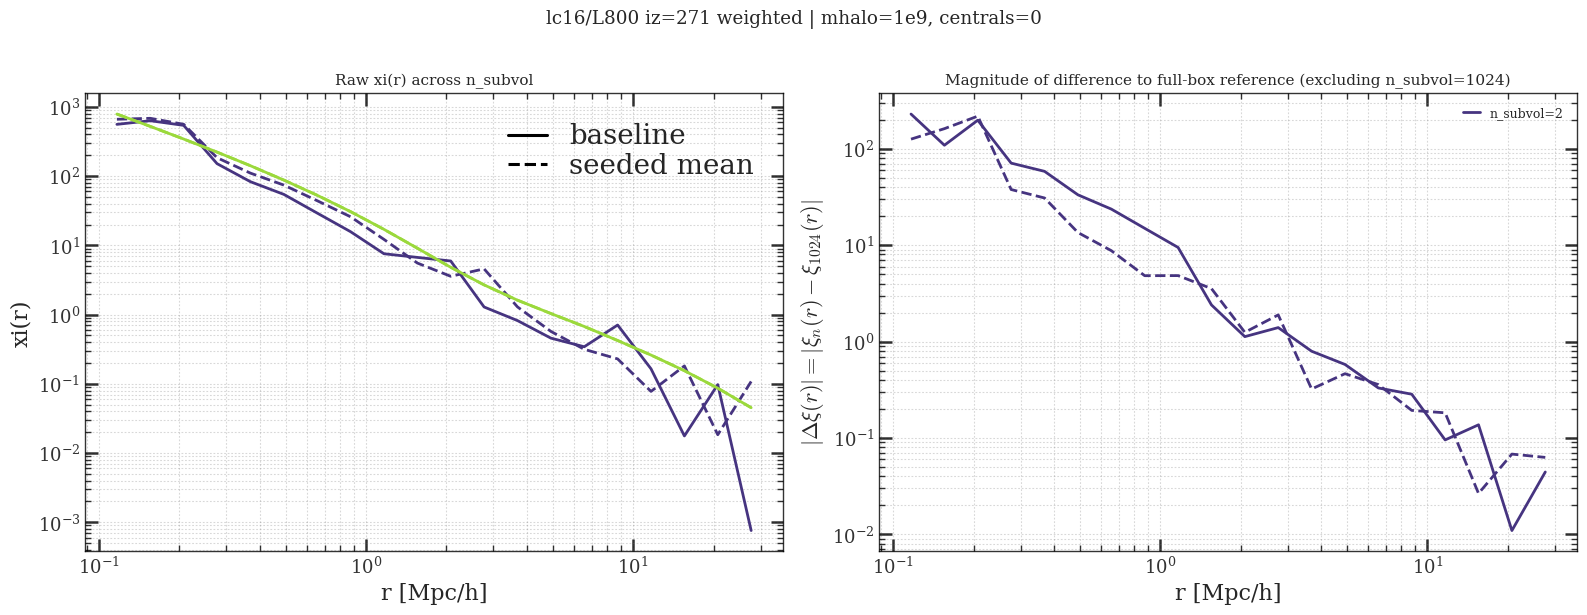

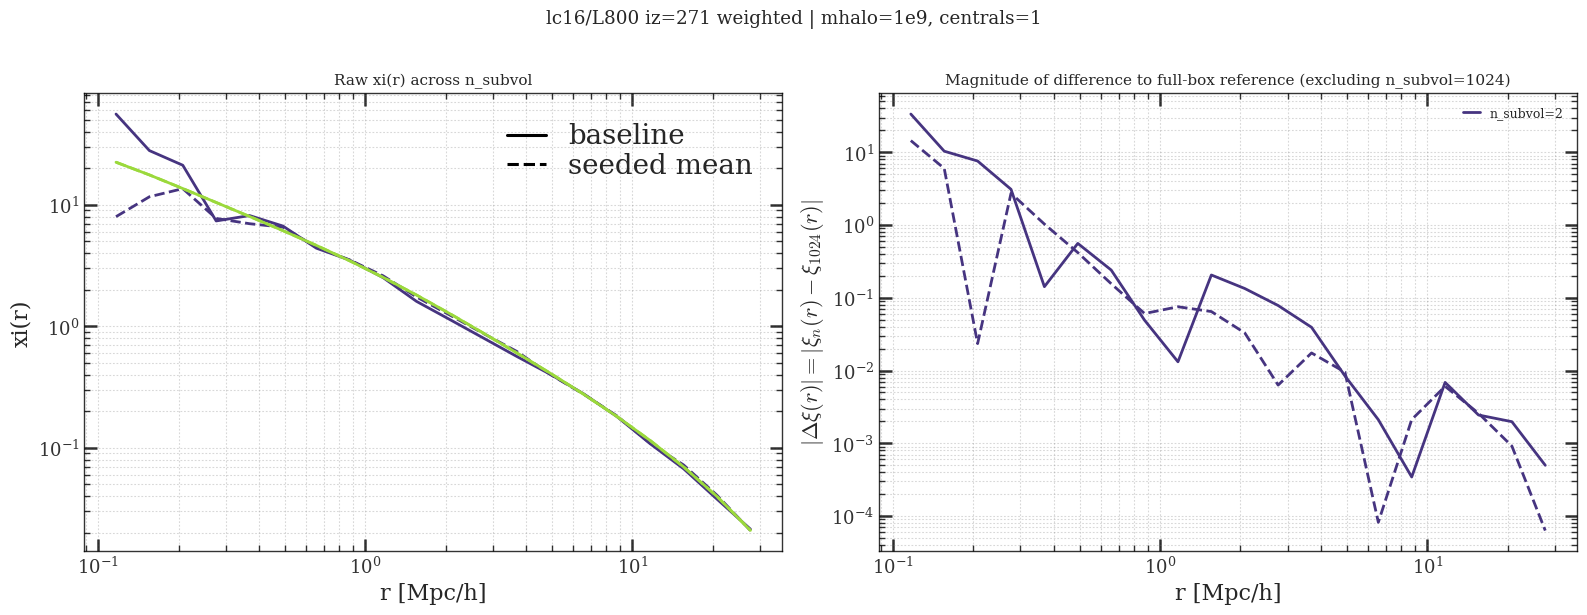

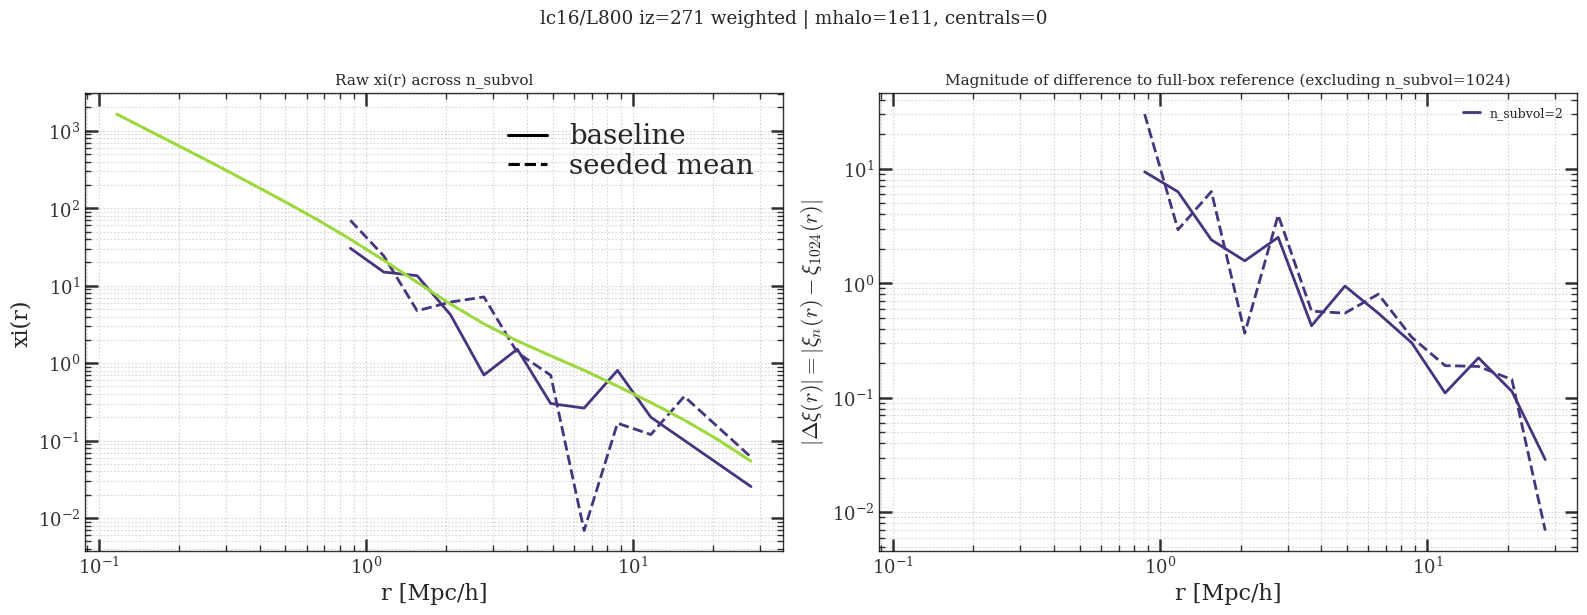

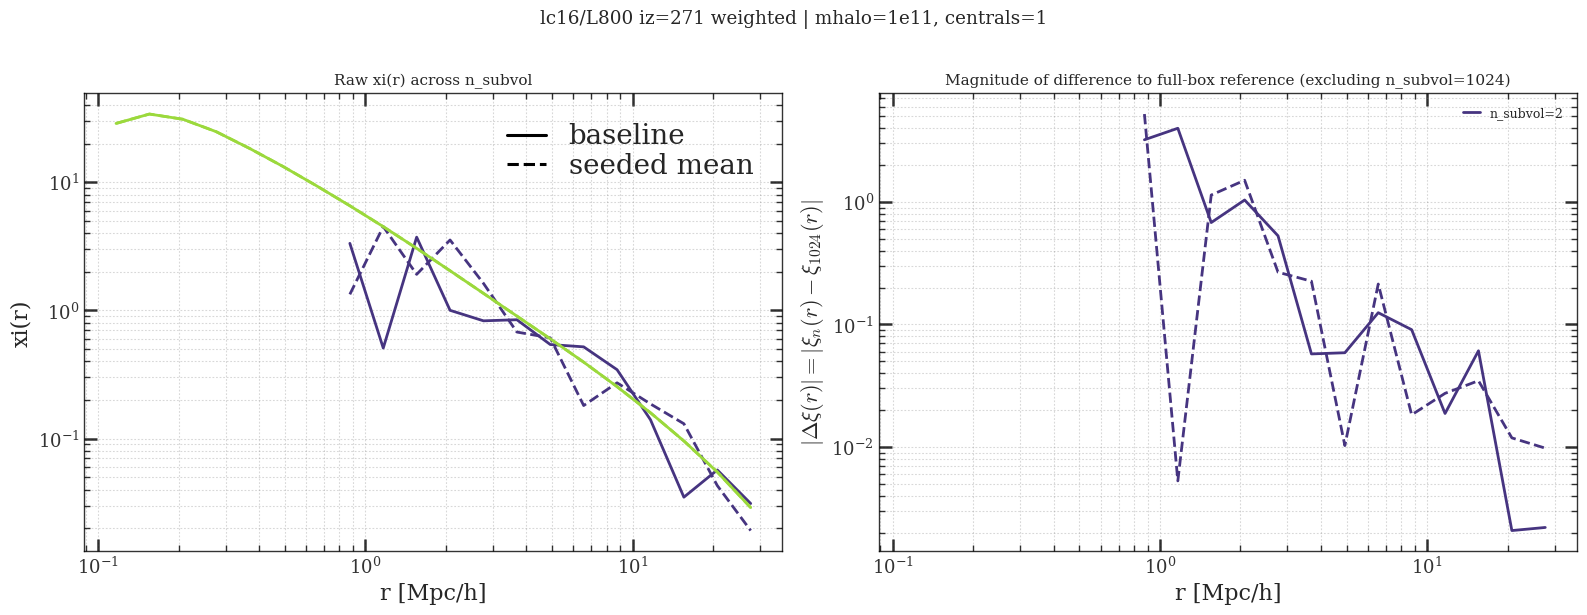

In [60]:
from matplotlib.lines import Line2D

PLOT_2PCF_CONV_MAX_COMBOS = 4
PLOT_2PCF_CONV_MAX_N_CURVES = 2  # keep only a small number of n_subvol curves for readability
PLOT_2PCF_CONV_CONVENTION = "auto"  # "auto", "xi", or "1+xi"
PLOT_2PCF_CONV_LARGE_SCALE_RMIN = 8.0

if baseline_raw.empty or seeded_raw.empty:
    print("Need both baseline and seeded raw data to run subvolume convergence plots.")
else:
    conv_base = baseline_raw.copy()
    conv_seed = seeded_raw.copy()

    for df in (conv_base, conv_seed):
        df["r"] = pd.to_numeric(df.get("r", np.nan), errors="coerce")
        df["xi"] = pd.to_numeric(df.get("xi", np.nan), errors="coerce")
        df["n_subvol"] = pd.to_numeric(df.get("n_subvol", np.nan), errors="coerce").astype("Int64")
        if "mode_norm" not in df.columns:
            df["mode_norm"] = df["mode"].map(MODE_MAP).fillna(df["mode"])

    if "selection_seed" not in conv_seed.columns:
        conv_seed["selection_seed"] = -1
    conv_seed["selection_seed"] = pd.to_numeric(conv_seed["selection_seed"], errors="coerce").fillna(-1).astype(int)

    conv_base = conv_base.dropna(subset=["r", "xi", "n_subvol"]).copy()
    conv_seed = conv_seed.dropna(subset=["r", "xi", "n_subvol"]).copy()

    xi_shift_conv, conv_label, base_tail_conv, seed_tail_conv = infer_xi_shift(
        conv_base,
        conv_seed,
        convention=PLOT_2PCF_CONV_CONVENTION,
        large_scale_rmin=PLOT_2PCF_CONV_LARGE_SCALE_RMIN,
    )
    print(
        f"Convergence xi convention (r>={PLOT_2PCF_CONV_LARGE_SCALE_RMIN}): "
        f"baseline median={base_tail_conv:.4g}, seeded median={seed_tail_conv:.4g}; "
        f"applying shift={xi_shift_conv:.1f} ({conv_label})."
    )

    combo_cols_2pcf = ["model", "sim", "iz", "mode_norm", "mhalo_tag", "centrals_only"]

    base_keys = set(conv_base[combo_cols_2pcf].drop_duplicates().itertuples(index=False, name=None))
    seed_keys = set(conv_seed[combo_cols_2pcf].drop_duplicates().itertuples(index=False, name=None))
    common_keys = base_keys.intersection(seed_keys)

    focus_keys = preferred_focus if "preferred_focus" in globals() else []
    combo_keys = [k for k in focus_keys if k in common_keys]
    if not combo_keys:
        combo_keys = sorted(common_keys)
    combo_keys = combo_keys[:PLOT_2PCF_CONV_MAX_COMBOS]

    if not combo_keys:
        print("No overlapping baseline-seeded combos found for convergence-style 2PCF plots.")
    else:
        def select_n_values(n_values, max_curves):
            n_values = sorted(set(int(n) for n in n_values))
            if len(n_values) <= max_curves:
                return n_values
            idx = np.unique(np.round(np.linspace(0, len(n_values) - 1, max_curves)).astype(int))
            sampled = [n_values[i] for i in idx]
            if n_values[-1] not in sampled:
                sampled.append(n_values[-1])
            return sorted(set(sampled))

        def mean_curve(df_combo, n_subvol):
            out = (
                df_combo[df_combo["n_subvol"].astype(int) == int(n_subvol)]
                .groupby("r", as_index=False)
                .agg(xi=("xi", "mean"))
                .sort_values("r")
            )
            out["xi_plot"] = out["xi"] - xi_shift_conv
            return out

        for key in combo_keys:
            model, sim, iz, mode_norm, mhalo_tag, centrals_only = key

            base_combo = conv_base[
                (conv_base["model"] == model)
                & (conv_base["sim"] == sim)
                & (conv_base["iz"] == iz)
                & (conv_base["mode_norm"] == mode_norm)
                & (conv_base["mhalo_tag"] == mhalo_tag)
                & (conv_base["centrals_only"] == centrals_only)
            ].copy()

            seed_combo = conv_seed[
                (conv_seed["model"] == model)
                & (conv_seed["sim"] == sim)
                & (conv_seed["iz"] == iz)
                & (conv_seed["mode_norm"] == mode_norm)
                & (conv_seed["mhalo_tag"] == mhalo_tag)
                & (conv_seed["centrals_only"] == centrals_only)
            ].copy()

            base_n = set(base_combo["n_subvol"].dropna().astype(int).tolist())
            seed_n = set(seed_combo["n_subvol"].dropna().astype(int).tolist())
            common_n = sorted(base_n.intersection(seed_n))

            if len(common_n) < 2:
                print(
                    f"Skipping {model}/{sim} iz={int(iz)} {mode_norm} mhalo={mhalo_tag} centrals={int(centrals_only)}: "
                    "need at least two common n_subvol values."
                )
                continue

            n_ref = common_n[-1]
            n_plot_values = select_n_values(common_n, PLOT_2PCF_CONV_MAX_N_CURVES)

            base_ref = mean_curve(base_combo, n_ref).rename(columns={"xi_plot": "xi_ref"})
            seed_ref = mean_curve(seed_combo, n_ref).rename(columns={"xi_plot": "xi_ref"})
            if base_ref.empty or seed_ref.empty:
                continue

            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
            ax_raw, ax_delta = axes

            colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(n_plot_values)))
            n_handles = []

            for color, n_subvol in zip(colors, n_plot_values):
                b = mean_curve(base_combo, n_subvol).merge(base_ref[["r", "xi_ref"]], on="r", how="inner")
                s = mean_curve(seed_combo, n_subvol).merge(seed_ref[["r", "xi_ref"]], on="r", how="inner")

                if b.empty or s.empty:
                    continue

                b_raw_mask = (b["r"] > 0) & np.isfinite(b["xi_plot"]) & (b["xi_plot"] > 0)
                s_raw_mask = (s["r"] > 0) & np.isfinite(s["xi_plot"]) & (s["xi_plot"] > 0)

                if b_raw_mask.any():
                    ax_raw.plot(b.loc[b_raw_mask, "r"], b.loc[b_raw_mask, "xi_plot"], color=color, lw=2.0, ls="-")
                if s_raw_mask.any():
                    ax_raw.plot(s.loc[s_raw_mask, "r"], s.loc[s_raw_mask, "xi_plot"], color=color, lw=2.0, ls="--")

                if int(n_subvol) == int(n_ref):
                    continue

                b_delta_mag = (b["xi_plot"] - b["xi_ref"]).abs()
                s_delta_mag = (s["xi_plot"] - s["xi_ref"]).abs()

                b_delta_mask = (b["r"] > 0) & np.isfinite(b_delta_mag) & (b_delta_mag > 0)
                s_delta_mask = (s["r"] > 0) & np.isfinite(s_delta_mag) & (s_delta_mag > 0)

                if b_delta_mask.any():
                    ax_delta.plot(b.loc[b_delta_mask, "r"], b_delta_mag[b_delta_mask], color=color, lw=2.0, ls="-")
                if s_delta_mask.any():
                    ax_delta.plot(s.loc[s_delta_mask, "r"], s_delta_mag[s_delta_mask], color=color, lw=2.0, ls="--")

                if b_delta_mask.any() or s_delta_mask.any():
                    n_handles.append(Line2D([0], [0], color=color, lw=2.0, label=f"n_subvol={n_subvol}"))

            style_handles = [
                Line2D([0], [0], color="black", lw=2.2, ls="-", label="baseline"),
                Line2D([0], [0], color="black", lw=2.2, ls="--", label="seeded mean"),
            ]

            ax_raw.set_xscale("log")
            ax_raw.set_yscale("log")
            ax_raw.grid(alpha=0.3, which="both")
            ax_raw.set_xlabel("r [Mpc/h]")
            ax_raw.set_ylabel("xi(r)")
            ax_raw.set_title("Raw xi(r) across n_subvol")
            ax_raw.legend(handles=style_handles, loc="upper right", frameon=False)

            ax_delta.set_xscale("log")
            ax_delta.set_yscale("log")
            ax_delta.grid(alpha=0.3, which="both")
            ax_delta.set_xlabel("r [Mpc/h]")
            ax_delta.set_ylabel(rf"$|\Delta\xi(r)|=|\xi_n(r)-\xi_{{{n_ref}}}(r)|$")
            ax_delta.set_title(f"Magnitude of difference to full-box reference (excluding n_subvol={n_ref})")
            if n_handles:
                ax_delta.legend(handles=n_handles, loc="upper right", frameon=False, fontsize=9, ncol=1)

            fig.suptitle(
                f"{model}/{sim} iz={int(iz)} {mode_norm} | mhalo={mhalo_tag}, centrals={int(centrals_only)}",
                y=1.02,
            )
            plt.tight_layout()
            plt.show()

## 4d) 2PCF Percentage Difference: Seeded vs Baseline

This section displays the percentage difference of the seeded 2PCF relative to the deterministic baseline result for each subvolume count:
$\Delta\xi(r) / \xi_{\mathrm{baseline}}(r) \times 100 = \frac{\xi_{\mathrm{seeded}}(r) - \xi_{\mathrm{baseline}}(r)}{\xi_{\mathrm{baseline}}(r)} \times 100$

This visually separates the curves (one curve per `n_subvol`) and directly answers how the seeded approach differs from the original deterministic outputs at various subvolume scales.

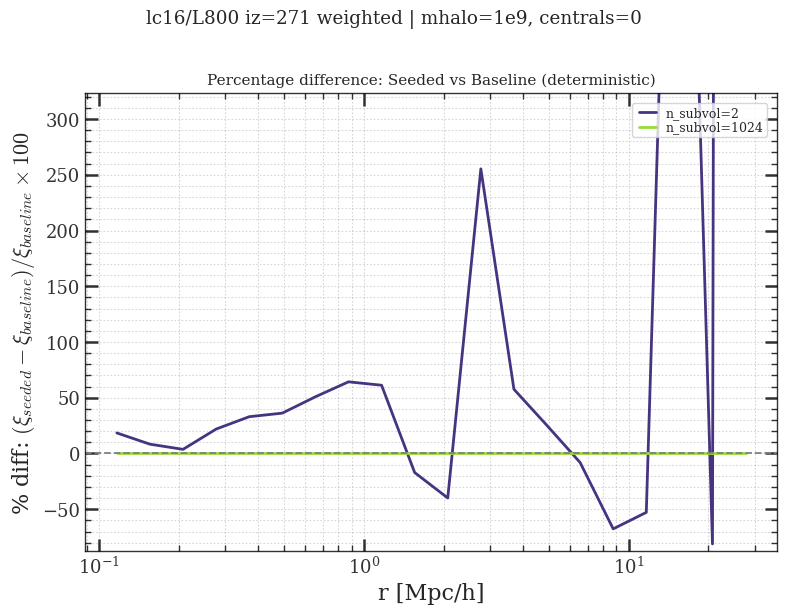

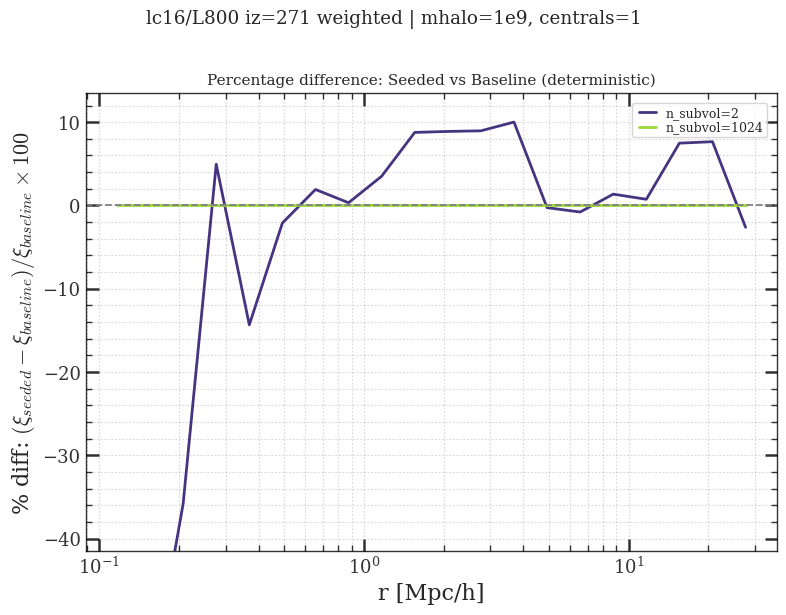

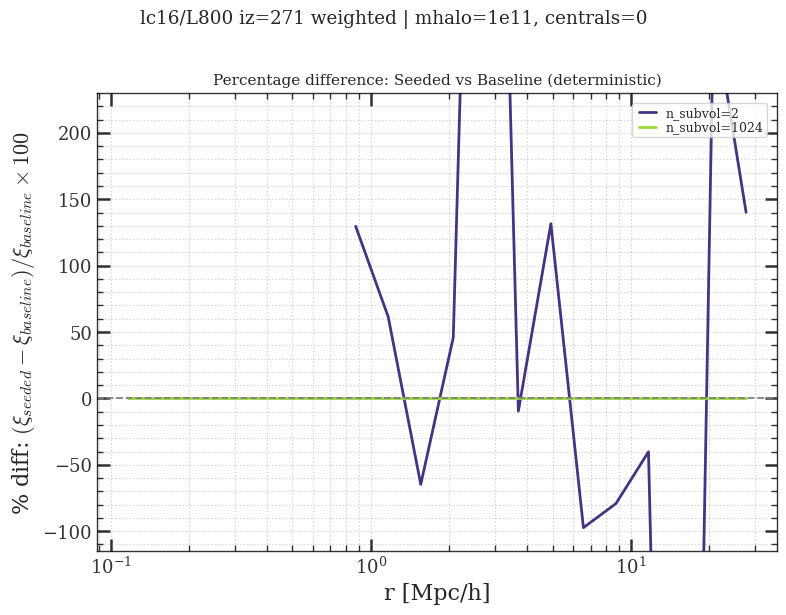

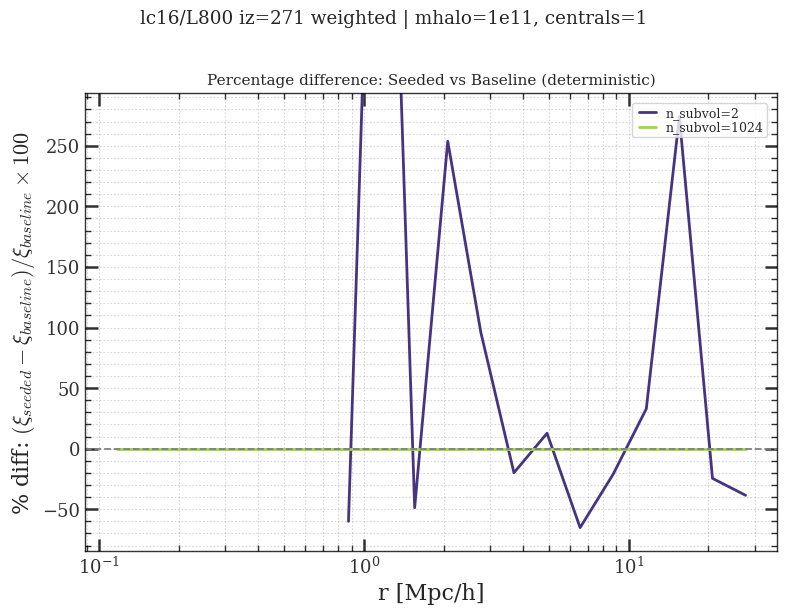

In [61]:
if baseline_raw.empty or seeded_raw.empty:
    print("Need both baseline and seeded raw data to run percentage difference plots.")
else:
    if not combo_keys:
        print("No overlapping baseline-seeded combos found for convergence-style 2PCF plots.")
    else:
        for key in combo_keys:
            model, sim, iz, mode_norm, mhalo_tag, centrals_only = key

            base_combo = conv_base[
                (conv_base["model"] == model)
                & (conv_base["sim"] == sim)
                & (conv_base["iz"] == iz)
                & (conv_base["mode_norm"] == mode_norm)
                & (conv_base["mhalo_tag"] == mhalo_tag)
                & (conv_base["centrals_only"] == centrals_only)
            ].copy()

            seed_combo = conv_seed[
                (conv_seed["model"] == model)
                & (conv_seed["sim"] == sim)
                & (conv_seed["iz"] == iz)
                & (conv_seed["mode_norm"] == mode_norm)
                & (conv_seed["mhalo_tag"] == mhalo_tag)
                & (conv_seed["centrals_only"] == centrals_only)
            ].copy()

            base_n = set(base_combo["n_subvol"].dropna().astype(int).tolist())
            seed_n = set(seed_combo["n_subvol"].dropna().astype(int).tolist())
            common_n = sorted(base_n.intersection(seed_n))

            if not common_n:
                continue

            n_plot_values = select_n_values(common_n, PLOT_2PCF_CONV_MAX_N_CURVES)

            fig, ax_pct = plt.subplots(1, 1, figsize=(8, 6))

            colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(n_plot_values)))
            n_handles = []
            all_pct = []

            for color, n_subvol in zip(colors, n_plot_values):
                b = mean_curve(base_combo, n_subvol).rename(columns={"xi_plot": "xi_base"})
                s = mean_curve(seed_combo, n_subvol).rename(columns={"xi_plot": "xi_seed"})

                if b.empty or s.empty:
                    continue

                merged = b[["r", "xi_base"]].merge(s[["r", "xi_seed"]], on="r", how="inner")
                merged_valid = merged[merged["xi_base"].abs() > 0].copy()

                if merged_valid.empty:
                    continue

                pct_diff = (merged_valid["xi_seed"] - merged_valid["xi_base"]) / merged_valid["xi_base"] * 100.0
                mask = (merged_valid["r"] > 0) & np.isfinite(pct_diff)

                if mask.any():
                    ax_pct.plot(merged_valid.loc[mask, "r"], pct_diff[mask], color=color, lw=2.0, ls="-")
                    n_handles.append(Line2D([0], [0], color=color, lw=2.0, label=f"n_subvol={n_subvol}"))
                    all_pct.extend(pct_diff[mask].tolist())

            ax_pct.axhline(0.0, color="gray", lw=1.3, ls="--")
            ax_pct.set_xscale("log")
            ax_pct.grid(alpha=0.3, which="both")
            ax_pct.set_xlabel("r [Mpc/h]")
            ax_pct.set_ylabel(r"% diff: $(\xi_{seeded}-\xi_{baseline})/\xi_{baseline}\times100$")
            ax_pct.set_title("Percentage difference: Seeded vs Baseline (deterministic)")

            if all_pct:
                lo = np.nanpercentile(all_pct, 5)
                hi = np.nanpercentile(all_pct, 95)
                pad = 0.1 * max(1.0, hi - lo)
                ax_pct.set_ylim(lo - pad, hi + pad)

            if n_handles:
                ax_pct.legend(handles=n_handles, loc="upper right", frameon=True, fontsize=9)

            fig.suptitle(
                f"{model}/{sim} iz={int(iz)} {mode_norm} | mhalo={mhalo_tag}, centrals={int(centrals_only)}",
                y=1.02,
            )
            plt.tight_layout()
            plt.show()

## 4e) What These Plots Demonstrate

Yes: the comparison is seeded sampling versus the deterministic baseline, at matched model/simulation/redshift/mass-cut selections.

Current coverage:
- Metric convergence (`metric/ref`) compares seeded and baseline trends over `n_subvol`.
- Raw 2PCF compares baseline and seeded mean at matched `n_subvol`.
- Convergence-style 2PCF panels compare how each method approaches the full-box reference.
- Percentage-difference panels show signed seeded-minus-baseline differences as a function of scale.

If needed, a final compact summary table can be added with one number per panel (for example median absolute % difference over $3 \le r \le 20$) to rank where seeded differs most.

## 5) Compute and Plot Pointwise Differences

Residuals are computed as seeded minus baseline in metric/ref at matched $(n_{\mathrm{subvol}}, \text{combo})$ points.

,model,sim,iz,mode_norm,mhalo_tag,centrals_only,n_subvol,mean_abs_diff,max_abs_diff,n_seed
0,lc16,L800,155,weighted,1e11,0,2,0.876458,0.876458,1
1,lc16,L800,155,weighted,1e11,0,4,1.257971,1.257971,1
2,lc16,L800,155,weighted,1e11,0,8,0.757464,0.757464,1
3,lc16,L800,155,weighted,1e11,0,10,0.884128,0.884128,1
4,lc16,L800,155,weighted,1e11,0,15,0.733012,0.733012,1
5,lc16,L800,155,weighted,1e11,0,20,0.266452,0.266452,1
6,lc16,L800,155,weighted,1e11,0,25,0.064995,0.064995,1
7,lc16,L800,155,weighted,1e11,0,30,0.005738,0.005738,1
8,lc16,L800,155,weighted,1e11,0,50,0.009465,0.009465,1
9,lc16,L800,155,weighted,1e11,0,100,0.015463,0.015463,1


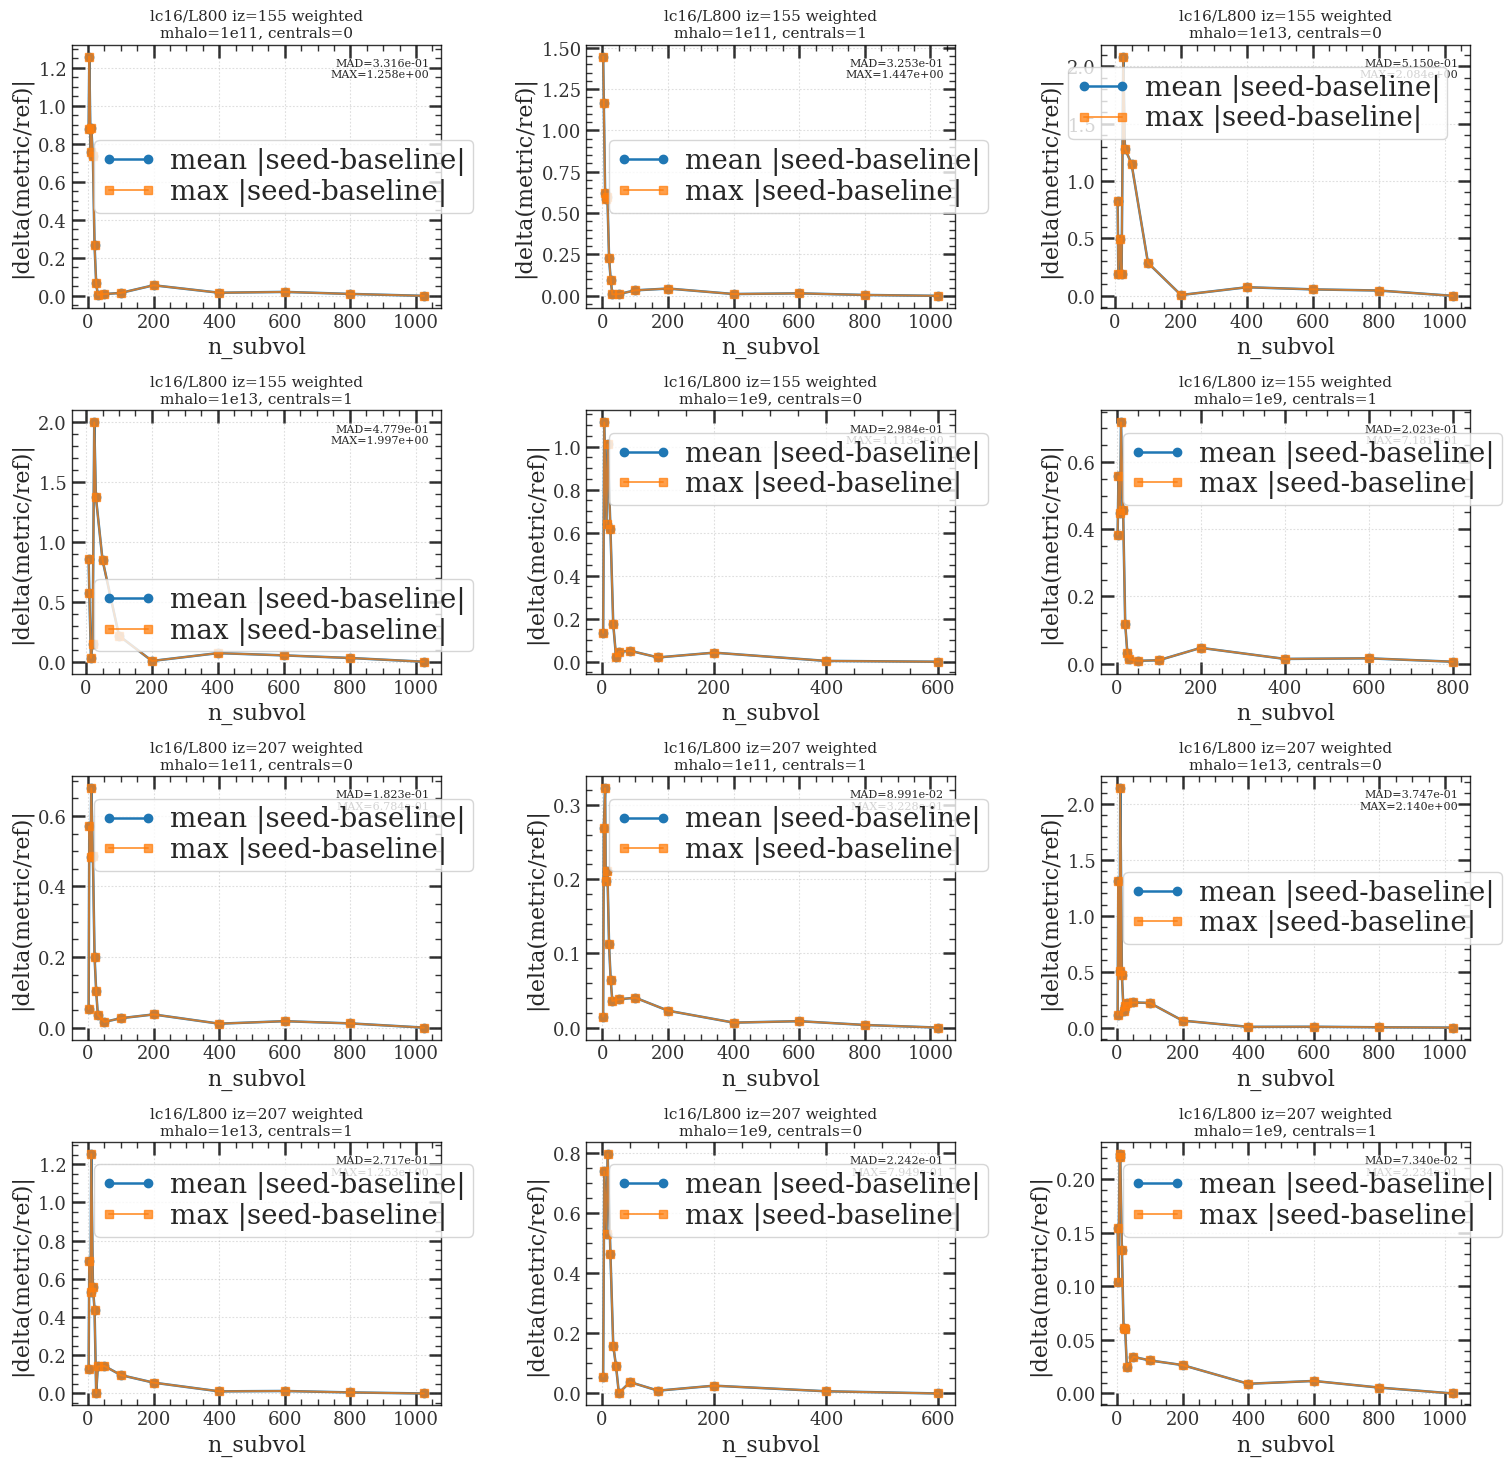

In [49]:
if SEEDED_CURVE.empty or BASELINE_CURVE.empty:
    print("Need both seeded and baseline curves to compute residuals.")
else:
    base_for_merge = BASELINE_CURVE[combo_cols + ["n_subvol", "frac_to_ref"]].rename(
        columns={"frac_to_ref": "frac_to_ref_baseline"}
    )
    delta = SEEDED_CURVE.merge(base_for_merge, on=combo_cols + ["n_subvol"], how="inner")
    delta["delta_frac"] = delta["frac_to_ref"] - delta["frac_to_ref_baseline"]

    if delta.empty:
        print("No matched seeded-baseline points found for residual calculation.")
    else:
        summary = (
            delta.groupby(combo_cols + ["n_subvol"], as_index=False)
            .agg(
                mean_abs_diff=("delta_frac", lambda s: np.mean(np.abs(s))),
                max_abs_diff=("delta_frac", lambda s: np.max(np.abs(s))),
                n_seed=("selection_seed", "nunique"),
            )
            .sort_values(combo_cols + ["n_subvol"])
        )

        display(summary.head(24))

        panel_df = summary[combo_cols].drop_duplicates().sort_values(combo_cols).head(MAX_PANELS)
        panels = [tuple(row) for row in panel_df.itertuples(index=False, name=None)]

        ncols = 3
        nrows = int(np.ceil(max(1, len(panels)) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.7 * nrows), squeeze=False)
        axes = axes.ravel()

        for i, key in enumerate(panels):
            ax = axes[i]
            model, sim, iz, mode_norm, mhalo_tag, centrals_only = key
            sdf = summary[
                (summary["model"] == model)
                & (summary["sim"] == sim)
                & (summary["iz"] == iz)
                & (summary["mode_norm"] == mode_norm)
                & (summary["mhalo_tag"] == mhalo_tag)
                & (summary["centrals_only"] == centrals_only)
            ].sort_values("n_subvol")

            ax.plot(sdf["n_subvol"], sdf["mean_abs_diff"], marker="o", lw=1.8, label="mean |seed-baseline|")
            ax.plot(sdf["n_subvol"], sdf["max_abs_diff"], marker="s", lw=1.4, alpha=0.75, label="max |seed-baseline|")
            ax.grid(alpha=0.25)
            ax.set_xlabel("n_subvol")
            ax.set_ylabel("|delta(metric/ref)|")
            ax.set_title(
                f"{model}/{sim} iz={int(iz)} {mode_norm}\nmhalo={mhalo_tag}, centrals={int(centrals_only)}"
            )

            mad_all = np.mean(sdf["mean_abs_diff"]) if len(sdf) else np.nan
            max_all = np.max(sdf["max_abs_diff"]) if len(sdf) else np.nan
            txt = f"MAD={mad_all:.3e}\nMAX={max_all:.3e}"
            ax.text(0.97, 0.95, txt, transform=ax.transAxes, ha="right", va="top", fontsize=8)
            ax.legend(loc="best", frameon=True)

        for j in range(len(panels), len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

## 6) Add Validation Cell for Reproducibility Check

This reruns the seeded-series selection using the same random seed and checks for exact equality.

In [50]:
def generate_seeded_view(seed_list, random_seed, max_panels=12):
    if SEEDED_CURVE_ALL.empty:
        return SEEDED_CURVE_ALL.copy(), pd.DataFrame(columns=combo_cols)

    if seed_list:
        view = SEEDED_CURVE_ALL[SEEDED_CURVE_ALL["selection_seed"].isin(seed_list)].copy()
    else:
        view = SEEDED_CURVE_ALL.copy()

    combos = view[combo_cols].drop_duplicates().sort_values(combo_cols).reset_index(drop=True)
    if len(combos) > max_panels:
        rng = np.random.default_rng(random_seed)
        keep_idx = np.sort(rng.choice(len(combos), size=max_panels, replace=False))
        combos = combos.iloc[keep_idx].reset_index(drop=True)

    view = view.sort_values(combo_cols + ["selection_seed", "n_subvol"]).reset_index(drop=True)
    return view, combos


view_a, combos_a = generate_seeded_view(FIXED_SEEDS, ANALYSIS_RANDOM_SEED, MAX_PANELS)
view_b, combos_b = generate_seeded_view(FIXED_SEEDS, ANALYSIS_RANDOM_SEED, MAX_PANELS)

same_view = view_a.equals(view_b)
same_combos = combos_a.equals(combos_b)

if same_view and same_combos:
    print("PASS: seeded view is reproducible with identical seed controls.")
else:
    print("FAIL: seeded view changed between repeated runs with same seed controls.")
    print("same_view:", same_view, "same_combos:", same_combos)

print(f"Rows checked: {len(view_a)} | Panel combos checked: {len(combos_a)}")

PASS: seeded view is reproducible with identical seed controls.
Rows checked: 264 | Panel combos checked: 12
